# Neural Networks from Scratch

In this notebook, we'll build our first Artificial Neural Network from scratch using only NumPy.

We'll learn how a neural network is constructed, how information flows through it, and why hidden layers make neural networks far more powerful than Logistic Regression.

**Topics Covered**

- Limitations of Logistic Regression
- Artificial Neurons
- Inputs, Weights and Biases
- Activation Functions
- Hidden Layers
- Matrix Representation
- Forward Propagation
- Building a Simple Neural Network

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## From Logistic Regression to Neural Networks

Before learning Neural Networks, let's briefly recall what we already know.

In Logistic Regression, we compute a weighted sum of the input features:

\[
z = wx + b
\]

where:

- \(x\) is the input
- \(w\) is the weight
- \(b\) is the bias

The result is then passed through the sigmoid activation function:

\[
a = \sigma(z)
\]

which produces a value between 0 and 1. This value can be interpreted as the probability of belonging to a particular class.

Notice something interesting.

A Logistic Regression model is simply a single mathematical unit that accepts some inputs, performs a weighted sum, applies an activation function, and produces an output.

This mathematical unit is exactly what we call an **artificial neuron**.

In other words,

> **A single neuron is mathematically equivalent to Logistic Regression.**

So why do we need Neural Networks?

Because a single neuron is often too simple to solve real-world problems.

## Why Logistic Regression Isn't Enough

Imagine trying to separate two classes of data using a straight line.

If the data is arranged like this, Logistic Regression works perfectly.

```
● ● ● ● ●

--------------------

○ ○ ○ ○ ○
```

A single straight line can separate the two classes.

Now imagine a more complicated dataset.

```
        ● ● ●

    ○ ○     ○ ○

 ●               ●

    ○ ○     ○ ○

        ● ● ●
```

No single straight line can separate these classes correctly.

This type of data is called **non-linearly separable**.

Real-world datasets are full of complex relationships like this.

For example:

- A cat cannot be recognized from a single pixel.
- A handwritten digit cannot be identified using one straight line.
- Human language cannot be understood using one simple equation.

To solve these problems, we need a model capable of learning many intermediate patterns before making its final prediction.

This is exactly what Neural Networks do.

Instead of using a single neuron, they combine many neurons together into multiple layers, allowing the model to learn increasingly complex representations of the data.

## Biological Inspiration

The term **Neural Network** comes from the human brain.

The human brain contains billions of specialized cells called **neurons**. These neurons communicate with one another by sending electrical and chemical signals through connections called **synapses**.

A biological neuron receives signals from many other neurons, processes the information, and then decides whether to pass a signal to the next neuron.

Although Artificial Neural Networks are inspired by this idea, they are **not simulations of the human brain**.

Instead, an artificial neuron is simply a mathematical function that receives several inputs, performs a calculation, and produces an output.

The goal of an artificial neuron is not to mimic biology perfectly, but to learn useful patterns from data.

As we connect many artificial neurons together into multiple layers, they become capable of solving increasingly complex problems.

## The Artificial Neuron

Let's build the simplest possible artificial neuron.

Suppose a student has the following information:

- Hours Studied
- Attendance Percentage
- Assignment Score

We would like to predict whether the student will **Pass** or **Fail**.

Our neuron receives these three values as inputs.

```
Hours Studied --------\
                       \
Attendance -------------> Artificial Neuron -----> Output
                       /
Assignment Score -----/
```

Unlike ordinary mathematical formulas, not every input is equally important.

For example, Hours Studied may contribute more towards passing the exam than Attendance.

The neuron learns **how important each input is** by assigning a number called a **weight** to every input.

These weights are adjusted during training so that the neuron makes better predictions over time.

## Inputs, Weights and Bias

Suppose our three inputs are

- Hours Studied = \(x_1\)
- Attendance = \(x_2\)
- Assignment Score = \(x_3\)

The neuron assigns one weight to each input.

- \(w_1\)
- \(w_2\)
- \(w_3\)

Each input is multiplied by its corresponding weight.

\[
w_1x_1,\;
w_2x_2,\;
w_3x_3
\]

These weighted inputs are then added together.

Finally, a value called the **bias** (\(b\)) is added.

The complete equation becomes

\[
z = w_1x_1 + w_2x_2 + w_3x_3 + b
\]

This equation is called the **weighted sum** or the **linear combination**.

Notice something familiar.

In Logistic Regression, we also computed

\[
z = wx + b
\]

The only difference is that we now have **multiple input features**, each with its own weight.

So far, our artificial neuron is mathematically identical to Logistic Regression.

In [2]:
# Example inputs

hours_studied = 8
attendance = 90
assignment_score = 85

# Example weights

w1 = 0.4
w2 = 0.2
w3 = 0.3

# Bias

b = -20

# Weighted sum

z = (
    w1 * hours_studied
    + w2 * attendance
    + w3 * assignment_score
    + b
)

print(f"Weighted Sum (z): {z:.2f}")

Weighted Sum (z): 26.70


## Activation Functions

The weighted sum (\(z\)) that we calculated is simply a number.

For example, depending on the inputs and weights, \(z\) could be:

- -12.4
- 0.8
- 15.7
- 120.5

By itself, this value doesn't tell us much.

If we are building a classifier, we usually want an output that is easy to interpret—for example, a probability between **0 and 1**.

This is the job of an **activation function**.

An activation function takes the weighted sum (\(z\)) as input and transforms it into another value.

Different activation functions produce different types of outputs and are suitable for different tasks.

Some common activation functions include:

- Sigmoid
- Tanh
- ReLU
- Leaky ReLU
- Softmax

In this notebook, we'll use the **Sigmoid** activation function because it is the simplest one and you have already seen it in Logistic Regression.

We'll explore the other activation functions in later notebooks.

## The Sigmoid Activation Function

The Sigmoid function converts any real number into a value between **0 and 1**.

Its mathematical equation is

\[
\sigma(z)=\frac{1}{1+e^{-z}}
\]

Some examples are shown below.

| Weighted Sum (\(z\)) | Sigmoid Output |
|----------------------:|---------------:|
| -10 | 0.00005 |
| -2 | 0.119 |
| 0 | 0.5 |
| 2 | 0.881 |
| 10 | 0.99995 |

Notice an interesting property.

- Large negative values become numbers close to **0**.
- Large positive values become numbers close to **1**.
- When \(z=0\), the output is exactly **0.5**.

This makes the Sigmoid function ideal for binary classification problems, where the output can be interpreted as the probability of belonging to one of two classes.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [4]:
# Apply sigmoid to our weighted sum

output = sigmoid(z)

print(f"Neuron Output: {output:.4f}")

Neuron Output: 1.0000


In [5]:
# Observe how sigmoid behaves for different values

values = np.array([-10, -5, -2, 0, 2, 5, 10])

print("z\tSigmoid(z)")
print("-" * 20)

for value in values:
    print(f"{value}\t{sigmoid(value):.6f}")

z	Sigmoid(z)
--------------------
-10	0.000045
-5	0.006693
-2	0.119203
0	0.500000
2	0.880797
5	0.993307
10	0.999955


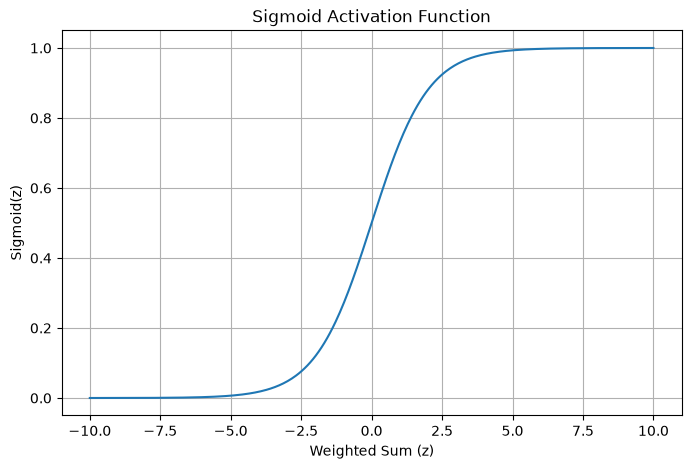

In [6]:
# Visualize the Sigmoid function

x = np.linspace(-10, 10, 400)
y = sigmoid(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y)

plt.title("Sigmoid Activation Function")
plt.xlabel("Weighted Sum (z)")
plt.ylabel("Sigmoid(z)")
plt.grid(True)

plt.show()

## Why Do We Need an Activation Function?

So far, our neuron performs two steps:

1. Compute the weighted sum

\[
z=w_1x_1+w_2x_2+\cdots+w_nx_n+b
\]

2. Apply an activation function

\[
a=\sigma(z)
\]

Together, these two equations define the output of a single artificial neuron.

Notice something important.

Without an activation function, every neuron would simply perform a linear calculation.

Even if we stacked hundreds of such neurons together, the entire network would still behave like one large linear model.

Activation functions introduce **non-linearity**, allowing Neural Networks to learn complex relationships that Linear and Logistic Regression cannot.

This is one of the fundamental ideas behind Deep Learning.

## From a Single Neuron to a Neural Network

A single artificial neuron can only learn relatively simple relationships.

To solve more complicated problems, we connect many neurons together.

This collection of interconnected neurons is called a **Neural Network**.

Instead of making one calculation, the data now passes through multiple neurons before reaching the final output.

Each neuron performs the same two operations:

1. Compute a weighted sum

\[
z = wx + b
\]

2. Apply an activation function

\[
a = \sigma(z)
\]

The output of one neuron becomes the input to another neuron.

By stacking neurons together, the network can gradually learn more complex patterns from the data.

## Layers in a Neural Network

Neurons are organized into **layers**.

A simple Neural Network consists of three types of layers.

### 1. Input Layer

The input layer receives the data.

Each feature in the dataset corresponds to one input neuron.

For example, if a student dataset contains:

- Hours Studied
- Attendance
- Assignment Score

then the input layer contains **three neurons**.

The input layer performs **no computation**. It simply passes the input values to the next layer.

---

### 2. Hidden Layer

The hidden layer performs the actual learning.

Each neuron in the hidden layer learns different patterns from the input data.

For example, one neuron may learn that studying is important, while another may learn that attendance has a stronger influence.

Most Neural Networks contain one or more hidden layers.

The more hidden layers a network has, the deeper the network becomes.

This is why the field is called **Deep Learning**.

---

### 3. Output Layer

The final layer produces the prediction.

For binary classification, there is usually **one output neuron** whose value represents the probability of belonging to the positive class.

## A Simple Neural Network

Suppose we have three input features:

- Hours Studied
- Attendance
- Assignment Score

We'll build a Neural Network with:

- 3 input neurons
- 2 hidden neurons
- 1 output neuron

It looks like this:

```

 [Input Layer]             [Hidden Layer]            [Output Layer]
                         
  ┌───────────────┐
  │ Hours Studied ├───────┐
  └───────────────┘       │       ┌───┐
                          ├──────►│ ○ │───────┐
  ┌───────────────┐       │       └───┘       │
  │  Attendance   ├───────┼─┐                 │        ┌───┐
  └───────────────┘       │ │                 ├───────►│ ○ │
                          │ │     ┌───┐       │        └───┘
  ┌───────────────┐       └─┼────►│ ○ │───────┘
  │ Assign. Score ├─────────┘     └───┘
  └───────────────┘

```

Each circle represents an artificial neuron.

Every neuron in one layer is connected to every neuron in the next layer.

Each connection has its own weight, and every neuron has its own bias.

Although this network looks much more complicated than Logistic Regression, remember that every circle still performs the exact same computation:

\[
z = wx + b
\]

followed by an activation function.

## How Information Flows Through the Network

Let's follow the journey of one input through the network.

### Step 1

The input features enter the input layer.

```
Hours Studied
Attendance
Assignment Score
```

↓

### Step 2

Each hidden neuron computes a weighted sum.

\[
z = wx + b
\]

↓

### Step 3

Each hidden neuron applies an activation function.

\[
a = \sigma(z)
\]

↓

### Step 4

The outputs of all hidden neurons become the inputs to the output neuron.

↓

### Step 5

The output neuron repeats the same process and produces the final prediction.

The important idea is that **every neuron performs the same mathematical operations**.

The only difference is the values of the weights and biases.

## Why Hidden Layers Are Powerful

Imagine trying to identify a handwritten digit.

A single neuron sees only the original pixel values.

A hidden layer can combine those pixels to detect simple patterns such as:

- Horizontal lines
- Vertical lines
- Corners
- Curves

The next hidden layer can combine these simple patterns into more meaningful shapes.

Finally, the output layer combines all of this information to recognize the complete digit.

This idea applies to many different problems.

For example:

- In image recognition, early layers detect edges, while deeper layers detect objects.
- In speech recognition, early layers detect sounds, while deeper layers recognize words.
- In language models, early layers learn grammar, while deeper layers capture meaning and context.

Each layer builds on the features learned by the previous layer, allowing Neural Networks to solve problems that are far beyond the capabilities of Linear or Logistic Regression.

## From Equations to Matrices

So far, we've represented the computation performed by a neuron as

\[
z = w_1x_1 + w_2x_2 + w_3x_3 + b
\]

This equation is easy to understand when we have only a few input features.

But imagine building a Neural Network with:

- 100 input features
- 500 hidden neurons
- Millions of training examples

Writing a separate equation for every neuron would quickly become impossible.

Instead, we use **vectors** and **matrices** to perform many calculations simultaneously.

This makes the mathematics cleaner and allows computers to perform these operations much more efficiently.

Fortunately, the underlying idea doesn't change—we're simply writing the same computation in a more compact form.

## Representing Inputs as Vectors

Instead of writing the inputs individually,

\[
x_1,\;x_2,\;x_3
\]

we combine them into a single **input vector**.

\[
X=
\begin{bmatrix}
x_1\\
x_2\\
x_3
\end{bmatrix}
\]

Similarly, instead of writing each weight separately,

\[
w_1,\;w_2,\;w_3
\]

we combine them into a **weight vector**.

\[
W=
\begin{bmatrix}
w_1\\
w_2\\
w_3
\end{bmatrix}
\]

Now the weighted sum becomes

\[
z = W^TX + b
\]

This equation is mathematically identical to

\[
z=w_1x_1+w_2x_2+w_3x_3+b
\]

The only difference is that we've replaced many individual multiplications and additions with a single matrix operation.

In [7]:
# Input vector

X = np.array([
    [8],
    [90],
    [85]
])

# Weight vector

W = np.array([
    [0.4],
    [0.2],
    [0.3]
])

bias = -20

# Weighted sum

z = W.T @ X + bias

print("Weighted Sum:")
print(z)

Weighted Sum:
[[26.7]]


## Verifying the Matrix Computation

Let's compare both approaches.

Using ordinary arithmetic,

\[
z =
0.4\times8
+
0.2\times90
+
0.3\times85
-20
\]

Using matrix multiplication,

\[
z=W^TX+b
\]

Both methods produce exactly the same result.

Matrix multiplication simply provides a compact and efficient way to perform the same computation.

This is one of the main reasons why NumPy is widely used in Machine Learning.

In [8]:
# Manual computation

manual = (
    0.4 * 8
    + 0.2 * 90
    + 0.3 * 85
    - 20
)

# Matrix computation

matrix = W.T @ X + bias

print(f"Manual Calculation : {manual:.2f}")
print(f"Matrix Calculation : {matrix[0,0]:.2f}")

Manual Calculation : 26.70
Matrix Calculation : 26.70


## Why Matrices Matter

So far, we've computed the output of **one neuron**.

But a Neural Network usually contains many neurons in each layer.

Suppose our hidden layer contains four neurons instead of one.

Each neuron has its own set of weights.

Instead of performing four separate calculations, we can store all the weights in a single **weight matrix**.

This allows NumPy to compute the outputs of all neurons simultaneously using a single matrix multiplication.

This is the foundation of modern Deep Learning.

Libraries such as TensorFlow and PyTorch use exactly this idea, allowing Neural Networks with millions or even billions of parameters to be trained efficiently.

## Building Our First Neural Network

Let's build a simple Neural Network with the following architecture:

```
Input Layer (3 neurons)
        │
        ▼
Hidden Layer (2 neurons)
        │
        ▼
Output Layer (1 neuron)
```

The network has:

- **3 input neurons**
  - Hours Studied
  - Attendance
  - Assignment Score
- **2 hidden neurons**
- **1 output neuron**

Remember that every neuron performs exactly the same computation:

1. Compute the weighted sum

\[
z = wx + b
\]

2. Apply the sigmoid activation function

The only difference between neurons is that each one has its own set of weights and bias.

In [9]:
# Input features
# Hours Studied, Attendance, Assignment Score

X = np.array([[8, 90, 85]])

print("Input:")
print(X)

print("\nShape:", X.shape)

Input:
[[ 8 90 85]]

Shape: (1, 3)


## Initializing the Parameters

A Neural Network learns by adjusting its **weights** and **biases**.

Before training begins, these values are initialized randomly.

Why random?

Imagine if every neuron started with exactly the same weights.

They would all produce identical outputs and learn exactly the same thing.

Random initialization ensures that different neurons learn different features from the data.

For our network:

- Input layer has **3 features**
- Hidden layer has **2 neurons**

Therefore,

the weight matrix connecting the input layer to the hidden layer must have shape

\[
(3,\;2)
\]

Each hidden neuron also has one bias.

So the bias vector has shape

\[
(1,\;2)
\]

In [10]:
np.random.seed(42)

# Input -> Hidden

W1 = np.random.randn(3, 2)
b1 = np.zeros((1, 2))

print("Weights (W1)")
print(W1)

print("\nBiases (b1)")
print(b1)

print("\nShapes")
print("W1:", W1.shape)
print("b1:", b1.shape)

Weights (W1)
[[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]
 [-0.23415337 -0.23413696]]

Biases (b1)
[[0. 0.]]

Shapes
W1: (3, 2)
b1: (1, 2)


## Hidden Layer Computation

The hidden layer receives the input matrix

\[
X
\]

and computes

\[
Z_1=XW_1+b_1
\]

where

- \(X\) contains the input features.
- \(W_1\) contains the weights connecting the input layer to the hidden layer.
- \(b_1\) contains the biases.

The result,

\[
Z_1,
\]

is called the **pre-activation** or **weighted sum**.

It is then passed through the sigmoid activation function.

\[
A_1=\sigma(Z_1)
\]

where

\[
A_1
\]

becomes the output of the hidden layer.

Notice something important.

Instead of computing two neurons separately, matrix multiplication computes both neurons simultaneously.

This is one of the biggest advantages of using matrices.

In [13]:
# Hidden layer weighted sum

Z1 = X @ W1 + b1

# Hidden layer activation

A1 = sigmoid(Z1)

print("Z1")
print(Z1)

print("\nA1")
print(A1)

print("\nShapes")
print("Z1:", Z1.shape)
print("A1:", A1.shape)

Z1
[[ 42.3626448  116.06493133]]

A1
[[1. 1.]]

Shapes
Z1: (1, 2)
A1: (1, 2)


## Understanding the Hidden Layer Output

Our hidden layer contains **two neurons**.

Therefore, after the forward pass, the output is

\[
A_1=
\begin{bmatrix}
a_1 & a_2
\end{bmatrix}
\]

Each value represents the output of one hidden neuron.

These values are **not the final prediction**.

Instead, they become the inputs to the next layer.

You can think of the hidden layer as extracting useful information from the original input before passing it to the output layer.

This process of learning intermediate representations is what makes Neural Networks so powerful.

## The Output Layer

The hidden layer has now transformed the original input into a new representation.

These transformed values become the input to the output layer.

Our output layer contains **one neuron**, so it produces a single prediction.

Just like the hidden layer, the output layer performs two steps.

### Step 1

Compute the weighted sum.

\[
Z_2 = A_1W_2 + b_2
\]

where

- \(A_1\) is the output from the hidden layer.
- \(W_2\) contains the weights connecting the hidden layer to the output layer.
- \(b_2\) is the bias of the output neuron.

### Step 2

Apply the sigmoid activation function.

\[
A_2 = \sigma(Z_2)
\]

The value of \(A_2\) becomes the final prediction of the neural network.

Notice that this is exactly the same computation we performed in the hidden layer.

Every layer in a neural network follows this same pattern.

In [14]:
# Hidden -> Output

W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

print("Weights (W2)")
print(W2)

print("\nBias (b2)")
print(b2)

print("\nShapes")
print("W2:", W2.shape)
print("b2:", b2.shape)

Weights (W2)
[[1.57921282]
 [0.76743473]]

Bias (b2)
[[0.]]

Shapes
W2: (2, 1)
b2: (1, 1)


In [15]:
# Output layer weighted sum

Z2 = A1 @ W2 + b2

# Final prediction

A2 = sigmoid(Z2)

print("Z2")
print(Z2)

print("\nA2")
print(A2)

print("\nShapes")
print("Z2:", Z2.shape)
print("A2:", A2.shape)

Z2
[[2.34664754]]

A2
[[0.91266739]]

Shapes
Z2: (1, 1)
A2: (1, 1)


## Understanding the Final Prediction

The output layer contains only one neuron.

Therefore, the network produces a single value.

For example,

\[
A_2 = 0.694
\]

Since we are using the sigmoid activation function, the output is always between **0 and 1**.

This value can be interpreted as the probability of belonging to the positive class.

For example,

- 0.10 → Very unlikely to belong to the positive class.
- 0.50 → The network is uncertain.
- 0.90 → Very likely to belong to the positive class.

Remember that our network has **not been trained** yet.

The weights were initialized randomly, so this prediction has no real meaning.

After training, the weights will gradually improve, allowing the network to make accurate predictions.

## The Complete Forward Pass

Let's summarize everything that happens when an input passes through our Neural Network.

### Input Layer

Receive the input features.

\[
X
\]

↓

### Hidden Layer

Compute the weighted sum.

\[
Z_1 = XW_1 + b_1
\]

↓

Apply the activation function.

\[
A_1 = \sigma(Z_1)
\]

↓

### Output Layer

Compute another weighted sum.

\[
Z_2 = A_1W_2 + b_2
\]

↓

Apply the activation function.

\[
A_2 = \sigma(Z_2)
\]

The value of \(A_2\) is the final prediction produced by the Neural Network.

This sequence of calculations is called **Forward Propagation** because information moves from the input layer to the output layer.

In [16]:
print("========== Forward Propagation ==========")

print("\nInput (X)")
print(X)

print("\nHidden Layer Weighted Sum (Z1)")
print(Z1)

print("\nHidden Layer Activation (A1)")
print(A1)

print("\nOutput Layer Weighted Sum (Z2)")
print(Z2)

print("\nFinal Prediction (A2)")
print(A2)

========== Forward Propagation ==========

Input (X)
[[ 8 90 85]]

Hidden Layer Weighted Sum (Z1)
[[ 42.3626448  116.06493133]]

Hidden Layer Activation (A1)
[[1. 1.]]

Output Layer Weighted Sum (Z2)
[[2.34664754]]

Final Prediction (A2)
[[0.91266739]]
